# 04e - Best Model Showcase

Based on the global evaluation, the **ARIMA** model has emerged as the best performer for both Daily Revenue and Daily Orders.

This notebook visualizes identifying exactly how this "Best Possible" model tracks against the actual data.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns

sns.set_style('whitegrid')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

df = pd.read_csv(ARTIFACTS_DIR / 'daily_series.csv', parse_dates=['date']).set_index('date')
print("Data loaded.")

Data loaded.


C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


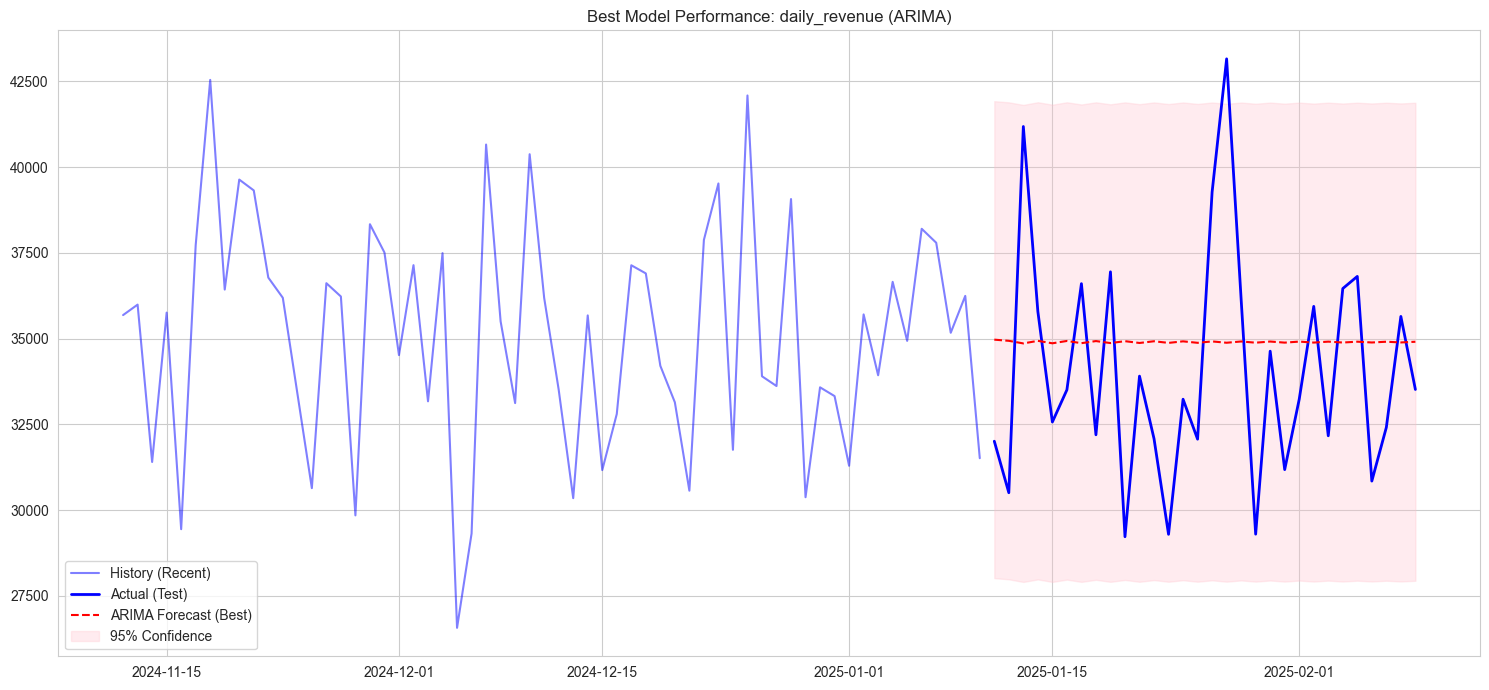

C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


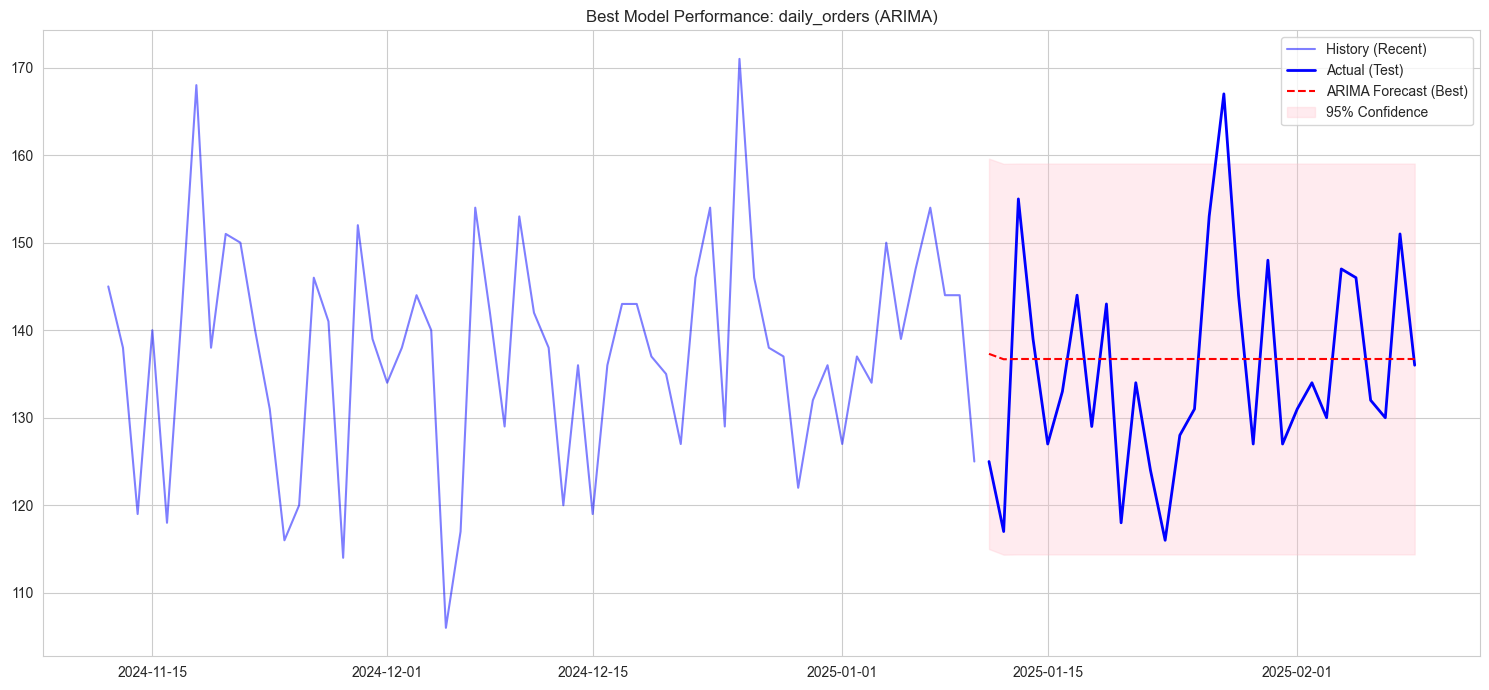

In [2]:
def plot_best_forecast(target_name, order=(1,1,1)):
    series = df[target_name].astype(float)
    train = series.iloc[:-30]
    test = series.iloc[-30:]
    
    # Fit the best model (ARIMA)
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    forecast_res = model_fit.get_forecast(steps=30)
    forecast = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int()
    
    plt.figure(figsize=(15, 7))
    plt.plot(train.iloc[-60:], label='History (Recent)', color='blue', alpha=0.5)
    plt.plot(test, label='Actual (Test)', color='blue', linewidth=2)
    plt.plot(forecast, label='ARIMA Forecast (Best)', color='red', linestyle='--')
    plt.fill_between(forecast.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence')
    
    plt.title(f'Best Model Performance: {target_name} (ARIMA)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04e_best_model_forecast_{target_name}.png')
    plt.show()

# Using common orders found during tuning
plot_best_forecast('daily_revenue', order=(2,1,2))
plot_best_forecast('daily_orders', order=(1,1,1))

C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


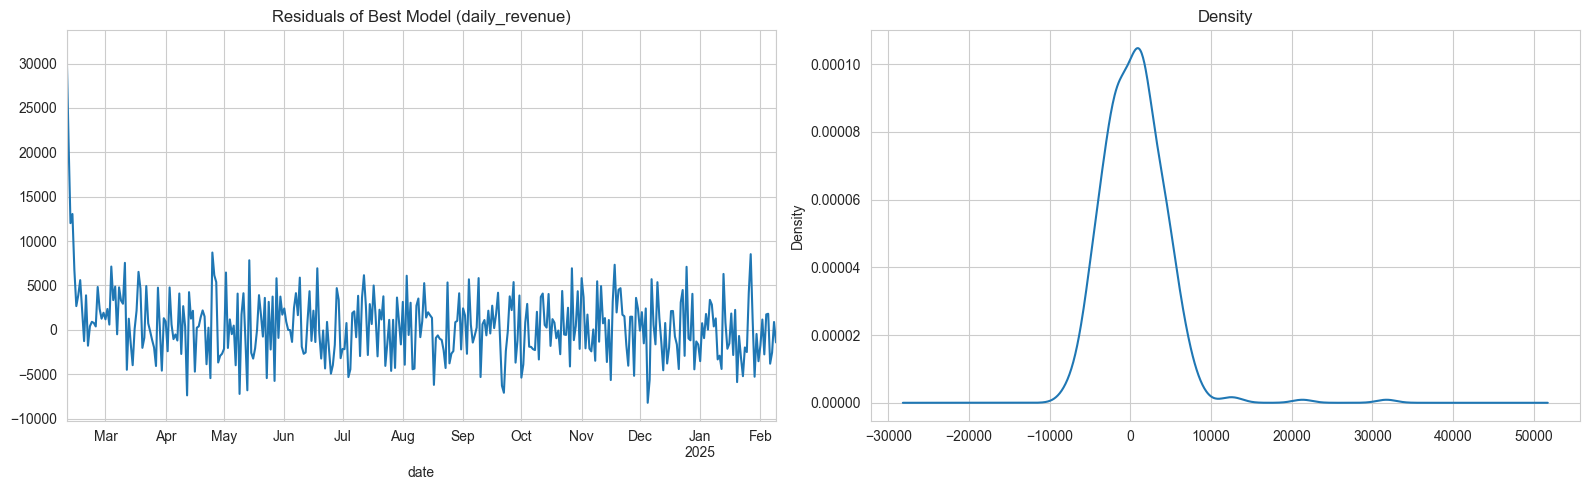

C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


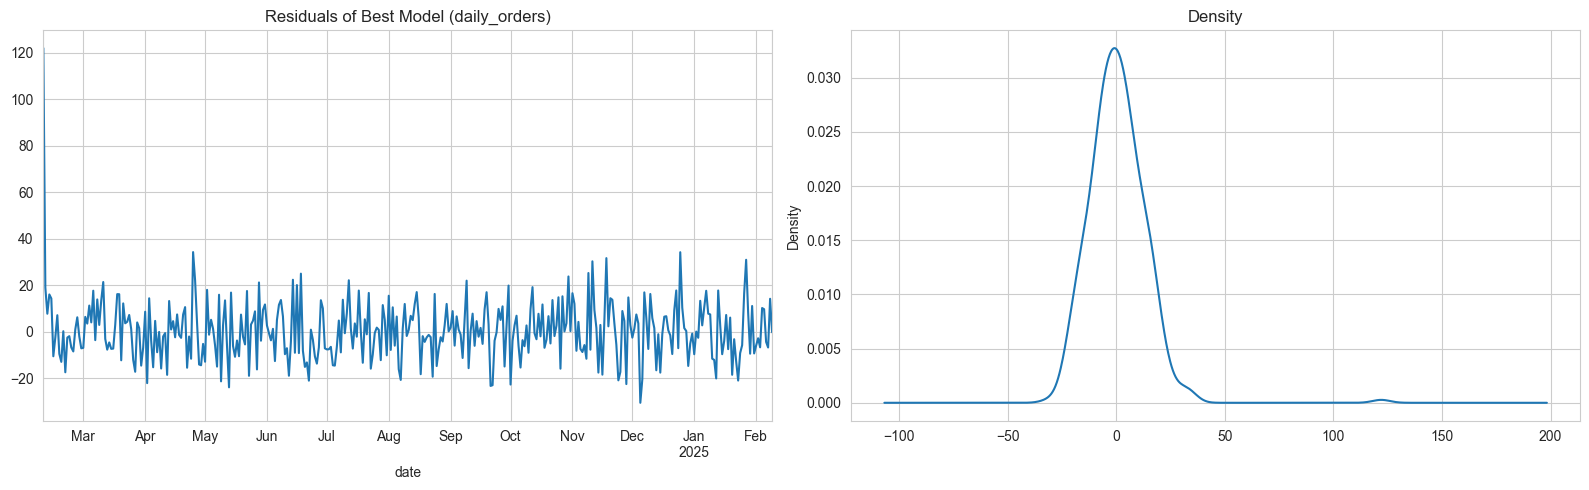

In [3]:
def plot_best_residuals(target_name, order=(1,1,1)):
    series = df[target_name].astype(float)
    model = ARIMA(series, order=order)
    model_fit = model.fit()
    
    residuals = model_fit.resid
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    residuals.plot(title=f'Residuals of Best Model ({target_name})', ax=ax1)
    residuals.plot(kind='kde', title='Density', ax=ax2)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04e_best_model_residuals_{target_name}.png')
    plt.show()

plot_best_residuals('daily_revenue', order=(2,1,2))
plot_best_residuals('daily_orders', order=(1,1,1))